In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('smart_cleaned.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Plot 1: Behavior Distribution

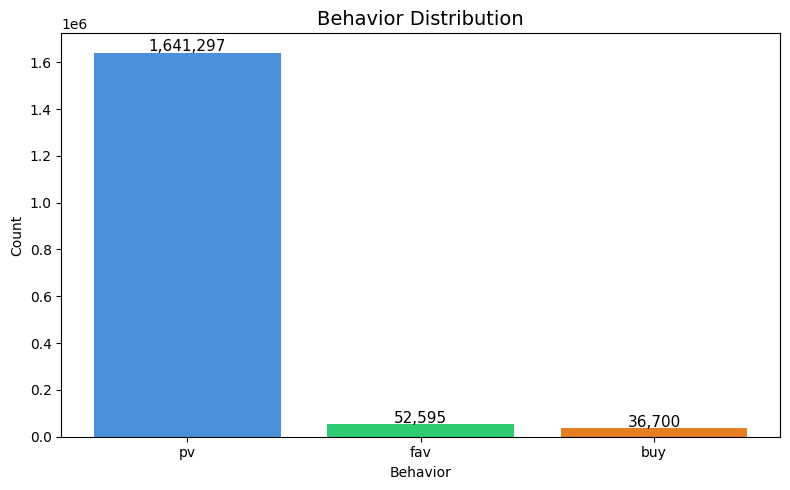

✅ Plot 1 done!


In [4]:
plt.figure(figsize=(8, 5))
colors = ['#4A90D9', '#2ECC71', '#E67E22']
behavior_counts = df['Behavior'].value_counts()
bars = plt.bar(behavior_counts.index, behavior_counts.values, color=colors)
plt.title('Behavior Distribution', fontsize=14)
plt.xlabel('Behavior')
plt.ylabel('Count')
for bar, v in zip(bars, behavior_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 5000, 
             f'{v:,}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('plot1_behavior.png', dpi=150)
plt.show()
print("✅ Plot 1 done!")

# Plot 2: Top 10 Categories by Score

C:\Users\kml_o\AppData\Local\Temp\ipykernel_52728\4169884044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index.astype(str), palette='viridis')


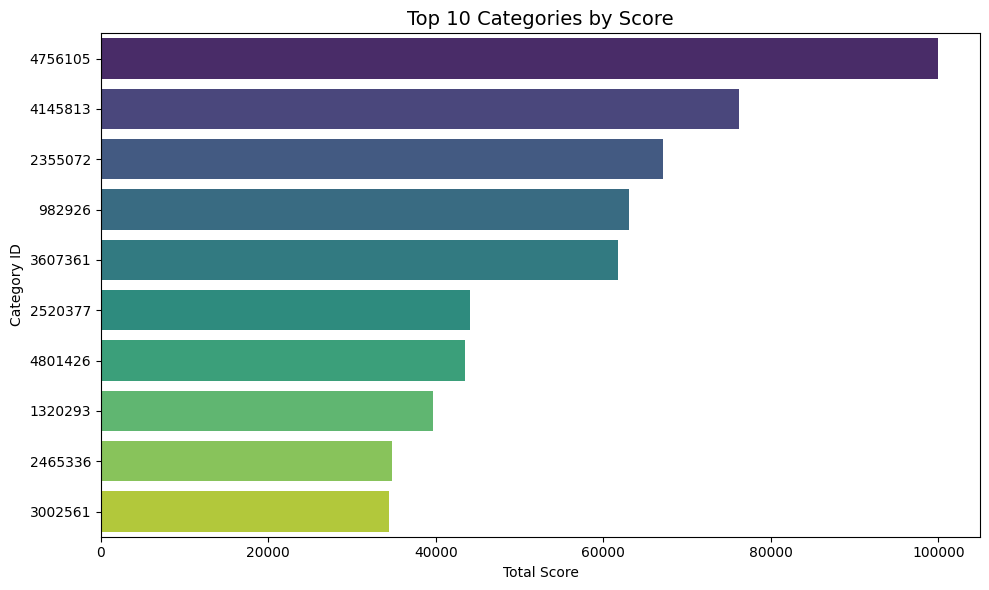

✅ Plot 2 done!


In [5]:
plt.figure(figsize=(10, 6))
top_cats = df.groupby('Category_ID')['Score'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_cats.values, y=top_cats.index.astype(str), palette='viridis')
plt.title('Top 10 Categories by Score', fontsize=14)
plt.xlabel('Total Score')
plt.ylabel('Category ID')
plt.tight_layout()
plt.savefig('plot2_top_categories.png', dpi=150)
plt.show()
print("✅ Plot 2 done!")

# Plot 3: User Activity Distribution

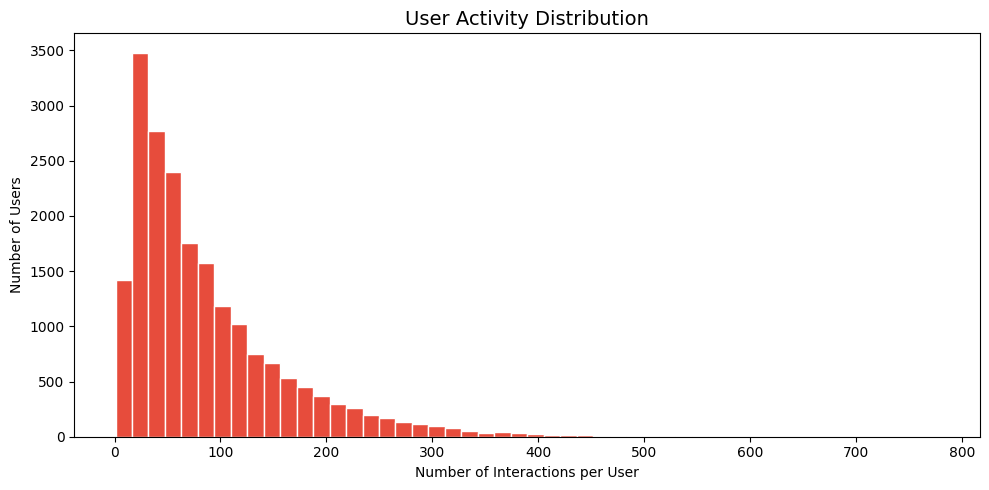

✅ Plot 3 done!


In [6]:
plt.figure(figsize=(10, 5))
user_activity = df.groupby('User_ID').size()
plt.hist(user_activity, bins=50, color='#E74C3C', edgecolor='white')
plt.title('User Activity Distribution', fontsize=14)
plt.xlabel('Number of Interactions per User')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig('plot3_user_activity.png', dpi=150)
plt.show()
print("✅ Plot 3 done!")

# Plot 4: Behavior by Hour

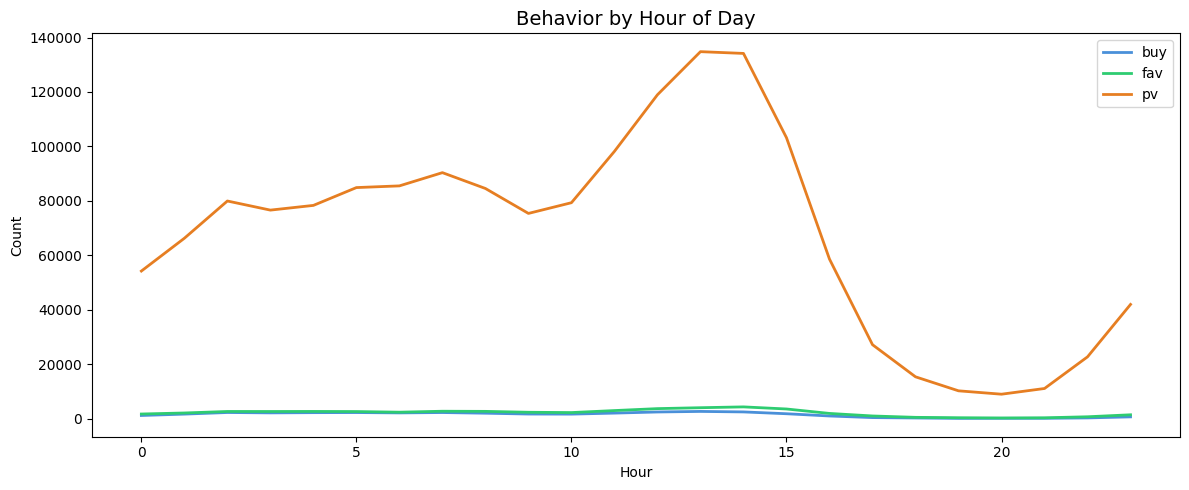

✅ Plot 4 done!


In [7]:
plt.figure(figsize=(12, 5))
df['Hour'] = df['DateTime'].dt.hour
hourly = df.groupby(['Hour', 'Behavior']).size().unstack(fill_value=0)
for col, color in zip(hourly.columns, ['#4A90D9', '#2ECC71', '#E67E22']):
    plt.plot(hourly.index, hourly[col], label=col, color=color, linewidth=2)
plt.title('Behavior by Hour of Day', fontsize=14)
plt.xlabel('Hour')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('plot4_hourly.png', dpi=150)
plt.show()
print("✅ Plot 4 done!")

# Plot 5: Daily Activity

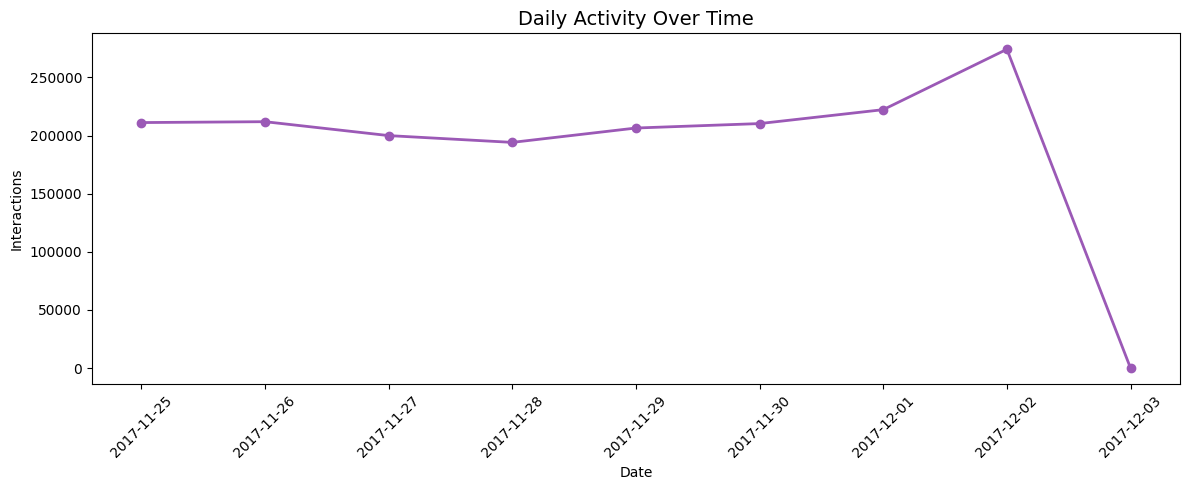

✅ Plot 5 done!


In [8]:
plt.figure(figsize=(12, 5))
df['Date'] = df['DateTime'].dt.date
daily = df.groupby('Date').size()
plt.plot(daily.index, daily.values, color='#9B59B6', linewidth=2, marker='o')
plt.title('Daily Activity Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Interactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot5_daily.png', dpi=150)
plt.show()
print("✅ Plot 5 done!")

# Key Stats

In [9]:
print("\n=== Key Stats ===")
print(f"Total interactions   : {len(df):,}")
print(f"Unique users         : {df['User_ID'].nunique():,}")
print(f"Unique products      : {df['Product_ID'].nunique():,}")
print(f"Unique categories    : {df['Category_ID'].nunique():,}")
print(f"Avg interactions/user: {len(df)/df['User_ID'].nunique():.1f}")
print(f"Buy rate             : {(df['Behavior']=='buy').sum()/len(df)*100:.2f}%")
print(f"Date range           : {df['DateTime'].min()} → {df['DateTime'].max()}")


=== Key Stats ===
Total interactions   : 1,730,592
Unique users         : 19,995
Unique products      : 590,266
Unique categories    : 6,484
Avg interactions/user: 86.6
Buy rate             : 2.12%
Date range           : 2017-11-25 00:00:00 → 2017-12-03 00:00:00


Plot 5 — Daily Activity
* Significant drop on December 3rd
* Because we set the filter to <= '2017-12-03', we only took the beginning of the day (00:00:00).

In [10]:
# نغير نهاية الـ range عشان ناخذ كامل يوم 3 ديسمبر
df = df[(df['DateTime'] >= '2017-11-25') & 
        (df['DateTime'] <= '2017-12-03 23:59:59')]

print(f"After fix: {df.shape}")
print(f"\nDaily counts:")
print(df.groupby(df['DateTime'].dt.date).size())

After fix: (1730592, 8)

Daily counts:
DateTime
2017-11-25    211189
2017-11-26    211944
2017-11-27    199981
2017-11-28    194144
2017-11-29    206498
2017-11-30    210321
2017-12-01    222293
2017-12-02    274218
2017-12-03         4
dtype: int64
